# Full research board — cross_miniflash

Synthesis of Phase 4 Promotes + application sims + **signal boards / info theory / stats / Bayesian**.

**Open these first** (also in `DESK_MEMO.md` / `applications/README.md`):

| Artifact | Path |
|----------|------|
| This notebook | `notebooks/full_research_board.ipynb` |
| Signal boards | `applications/signal_boards/signal_boards.ipynb` |
| Info theory | `applications/signal_boards/info_theory.ipynb` |
| Statistical | `applications/signal_boards/statistical.ipynb` |
| Bayesian | `applications/signal_boards/bayesian.ipynb` |
| Feature models | `applications/feature_models/severity_regime.ipynb` |
| MM quoting | `applications/mm_quoting/v_continuation_quoting.ipynb` |
| Strategy lab (equity) | `applications/strategy_lab/` |

Key PNGs under `applications/out/signal_boards/figs/`.


In [1]:

import json
from pathlib import Path
from IPython.display import Image, display, Markdown

BOOK = Path('..').resolve()
APP = BOOK / 'applications'
FIG = APP / 'out' / 'signal_boards' / 'figs'
SUM = APP / 'out' / 'signal_boards' / 'signal_boards_summary.json'
BOARD = APP / 'out' / 'applications_board.json'
s = json.loads(SUM.read_text()) if SUM.exists() else {}
b = json.loads(BOARD.read_text()) if BOARD.exists() else {}
print('signal_boards n_events', s.get('n_events'), 'figs', len(s.get('figs') or []))
print('applications board packages', list(b.keys())[:12] if isinstance(b, dict) else type(b))


signal_boards n_events 275 figs 19
applications board packages ['kill_ladder', 'nanex_burst', 'hl_thin_sor', 'hv_fei_capacity', 'mm_quoting', 'feature_models']


## Signal boards (Promote features)

**fig_gated_intensity_ts.png**

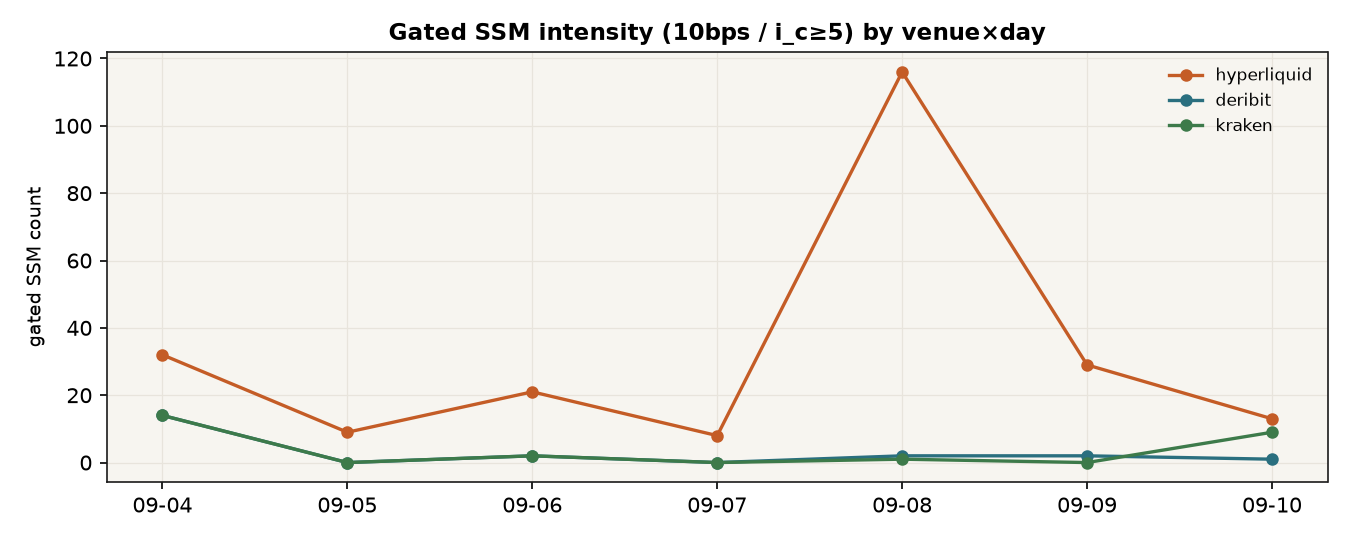

**fig_zstar_path_ts.png**

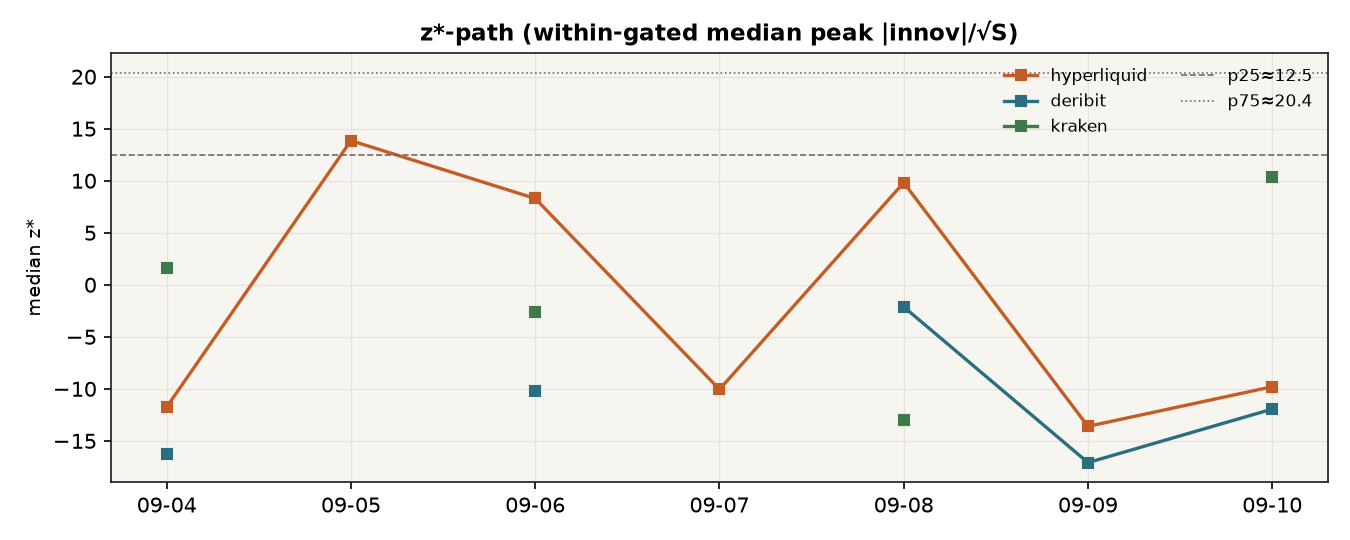

**fig_nanex_ssm_ts.png**

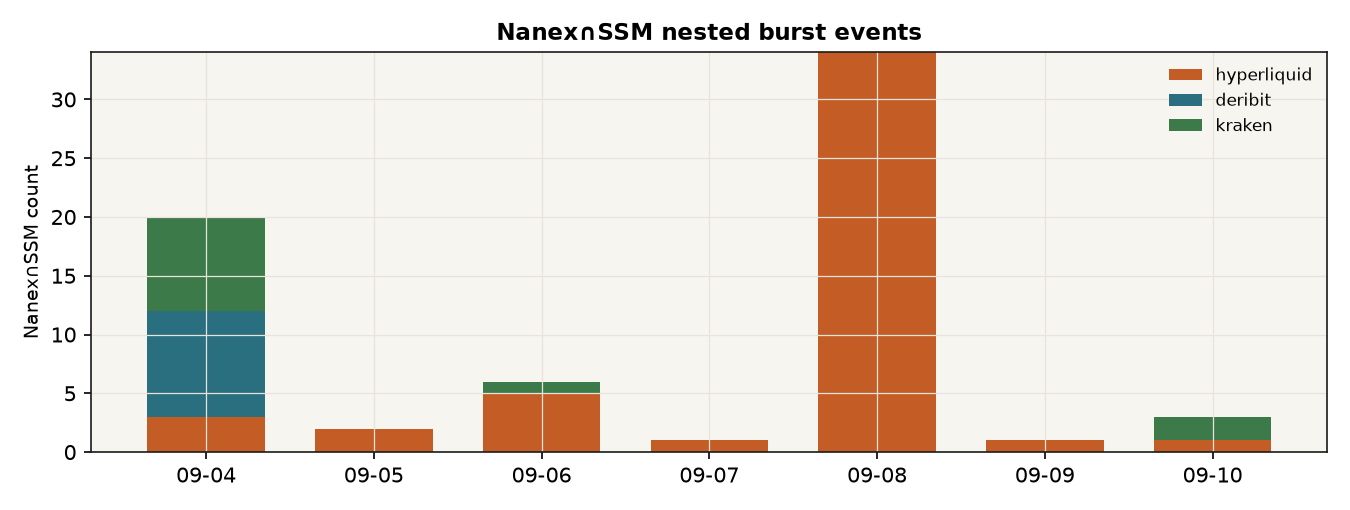

**fig_vpin_x_size_ts.png**

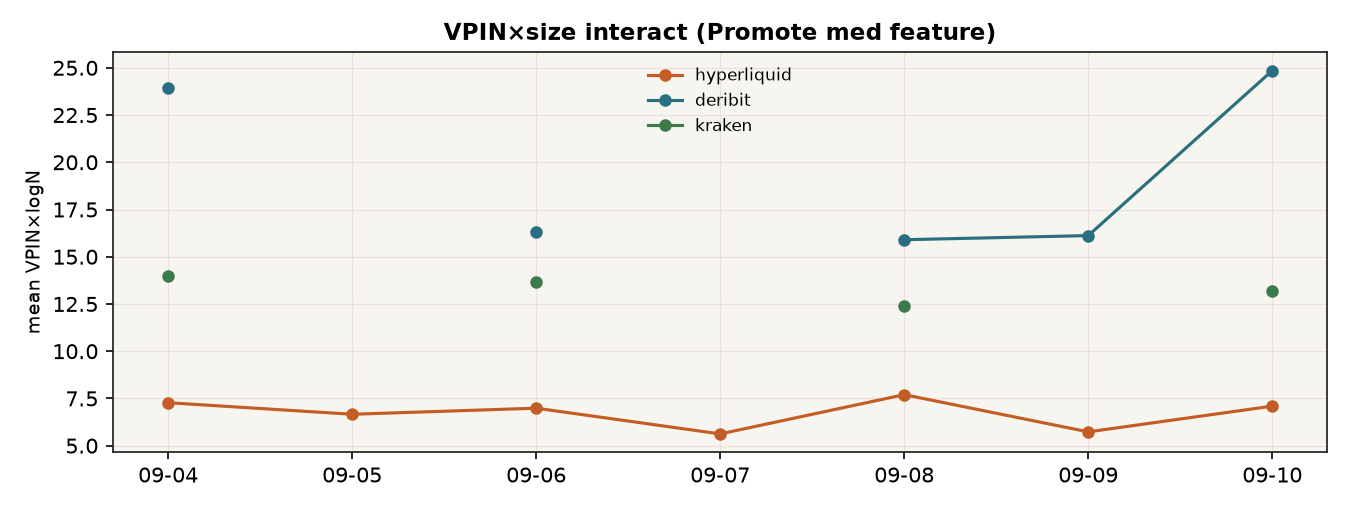

**fig_hv_fei_ts.png**

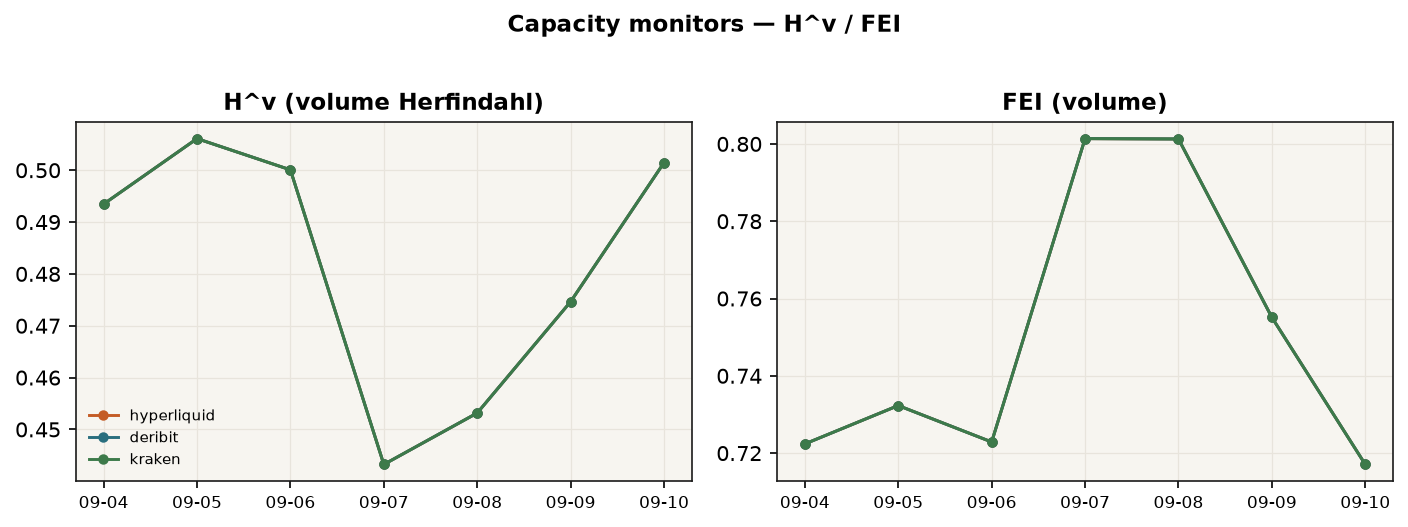

**fig_thin_excess_ts.png**

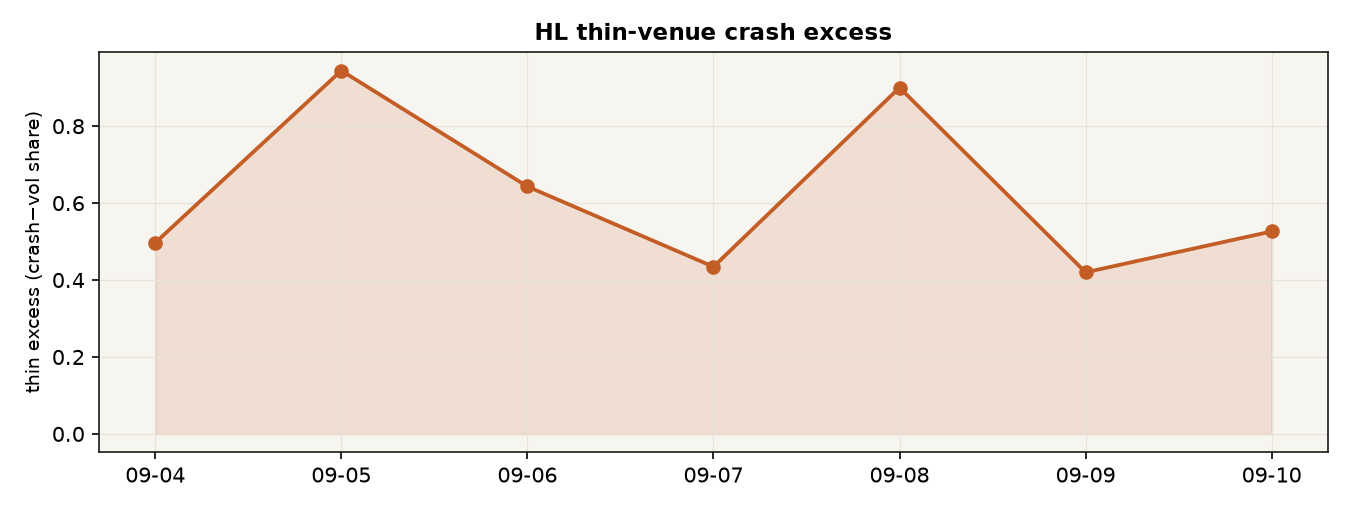

**fig_event_heatmaps.png**

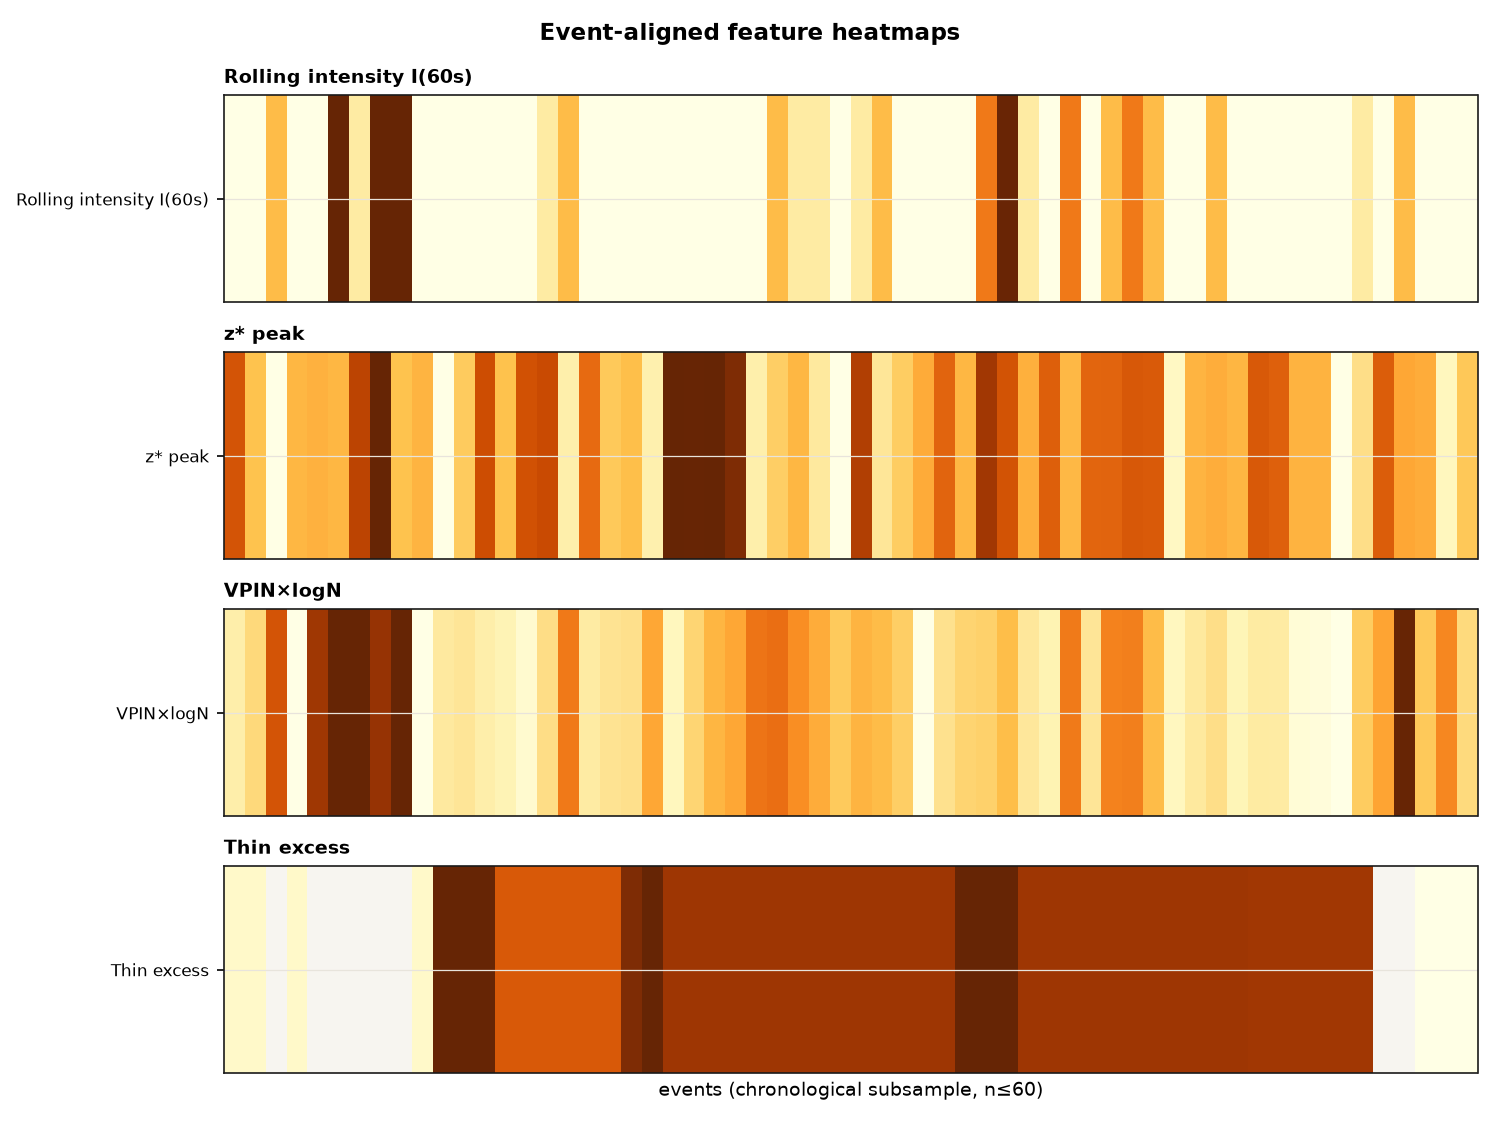

**fig_feature_vs_severity.png**

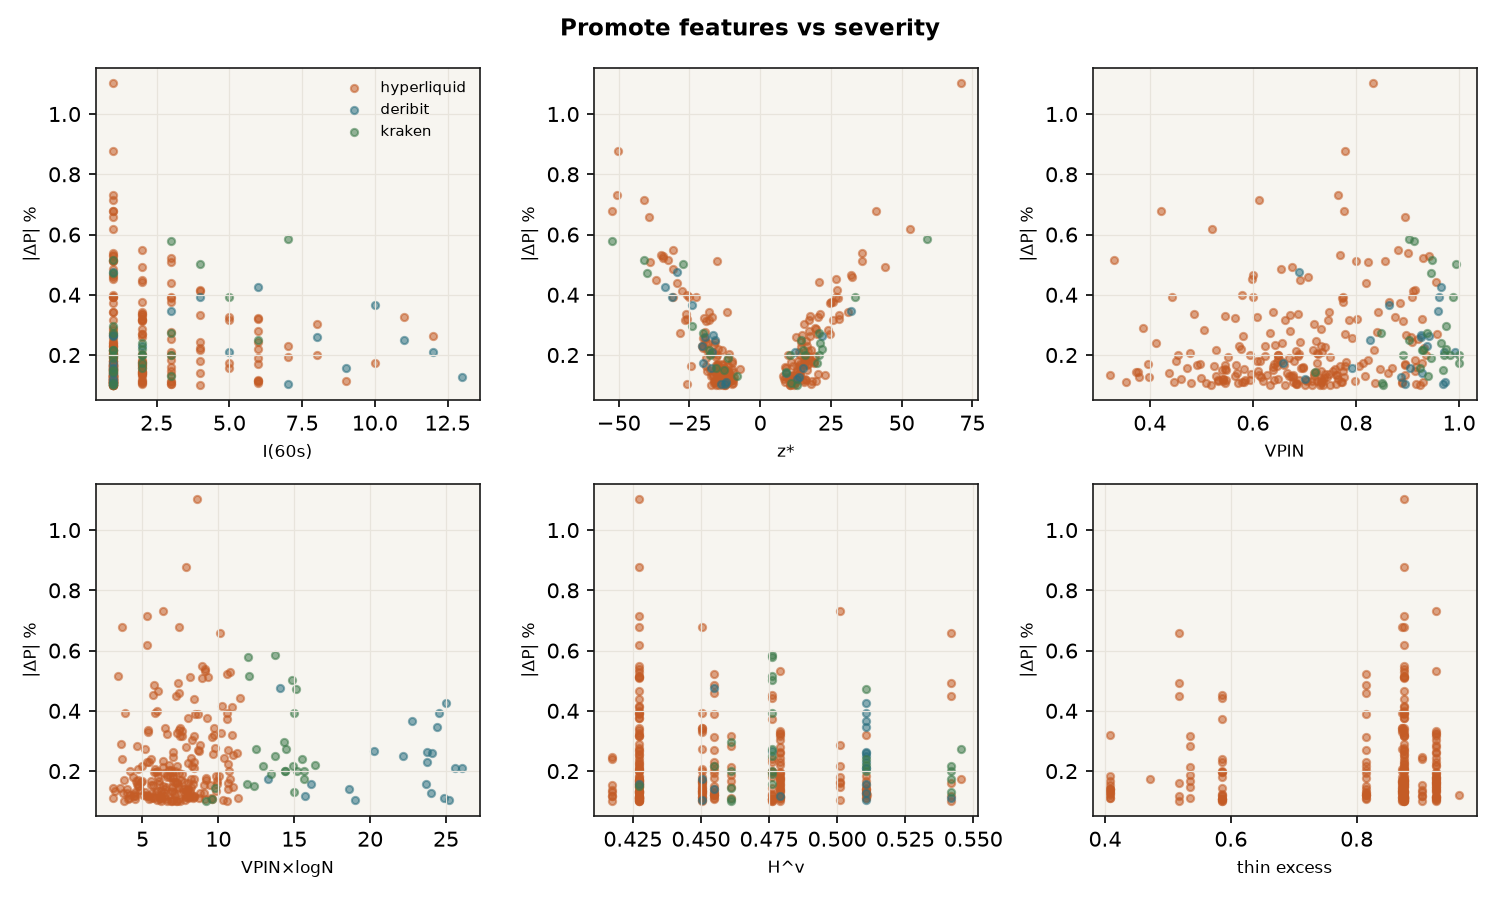

In [2]:

for name in [
    'fig_gated_intensity_ts.png','fig_zstar_path_ts.png','fig_nanex_ssm_ts.png',
    'fig_vpin_x_size_ts.png','fig_hv_fei_ts.png','fig_thin_excess_ts.png',
    'fig_event_heatmaps.png','fig_feature_vs_severity.png',
]:
    p = FIG/name
    display(Markdown(f'**{name}**'))
    if p.exists(): display(Image(filename=str(p)))


## Information theory

n_events=275 gated; occurrence halves n=84. MI estimates noisy; lagged TE-style scan is descriptive only — not causal claim.
venue H_bits 0.829291365577173


**fig_mi_event.png**

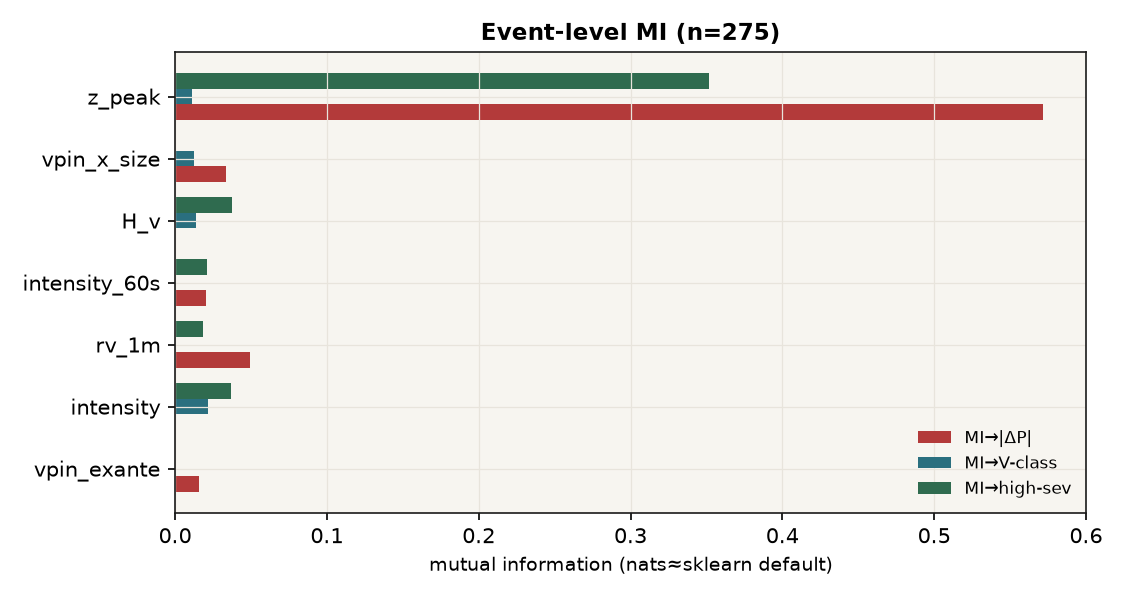

**fig_mi_occurrence.png**

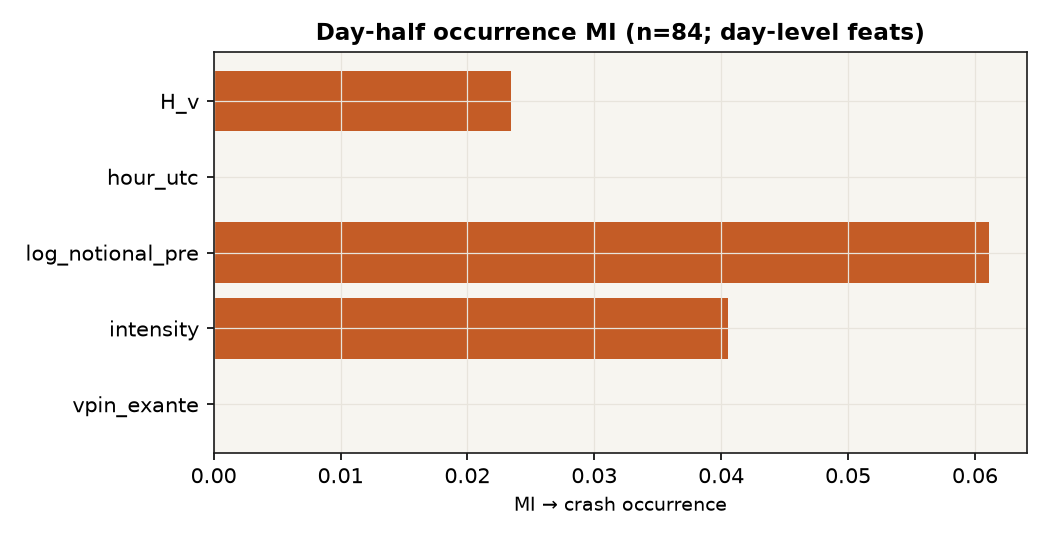

**fig_venue_entropy.png**

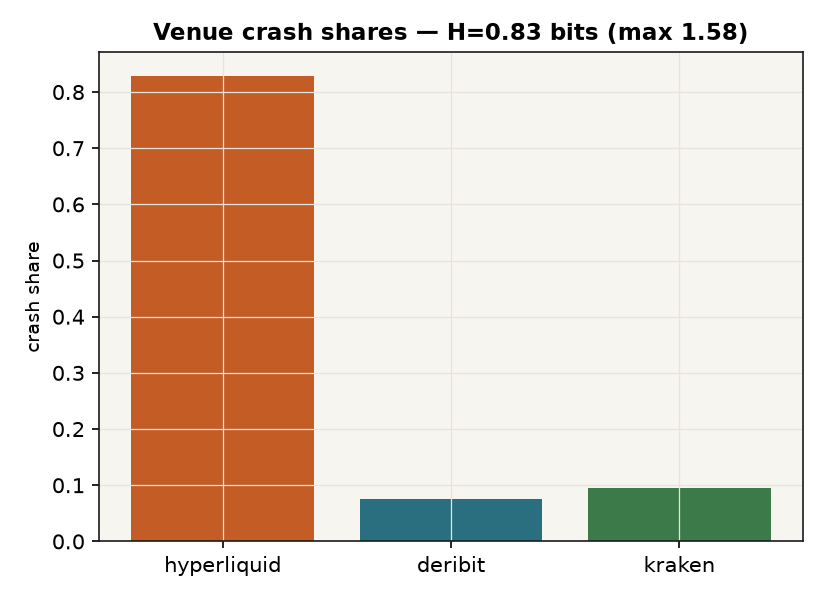

**fig_lagged_mi_scan.png**

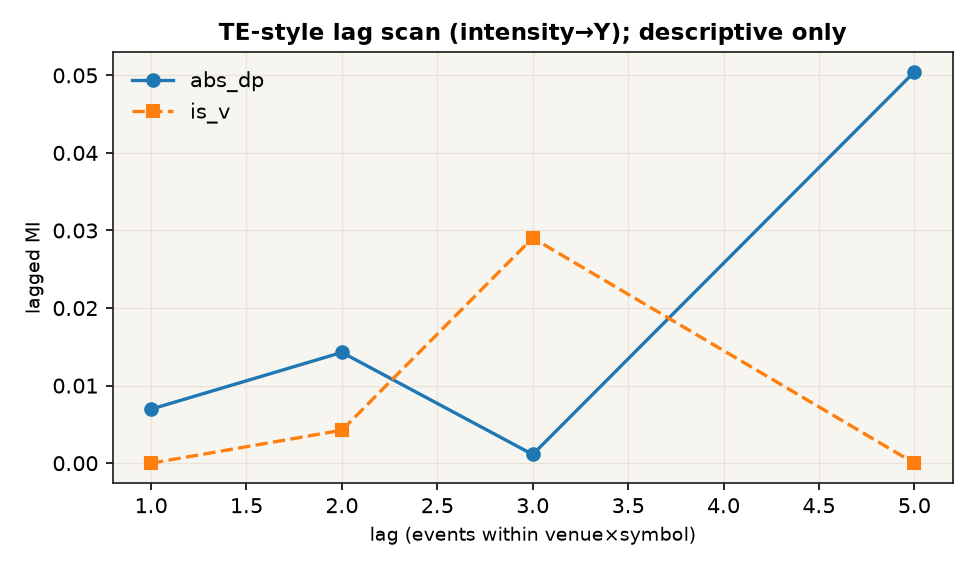

In [3]:

info = s.get('info_theory') or {}
print(info.get('sample_honesty'))
print('venue H_bits', (info.get('venue_crash_entropy') or {}).get('H_bits'))
for name in ['fig_mi_event.png','fig_mi_occurrence.png','fig_venue_entropy.png','fig_lagged_mi_scan.png']:
    display(Markdown(f'**{name}**'))
    display(Image(filename=str(FIG/name)))


## Statistical + Bayesian

ROC AUC 0.6354166666666667
V posterior 0.7689530685920578 [0.7177162808528023, 0.8172611388106471]
logistic AUC_te 0.7604166666666667 ppp 0.584


**fig_bootstrap_cis.png**

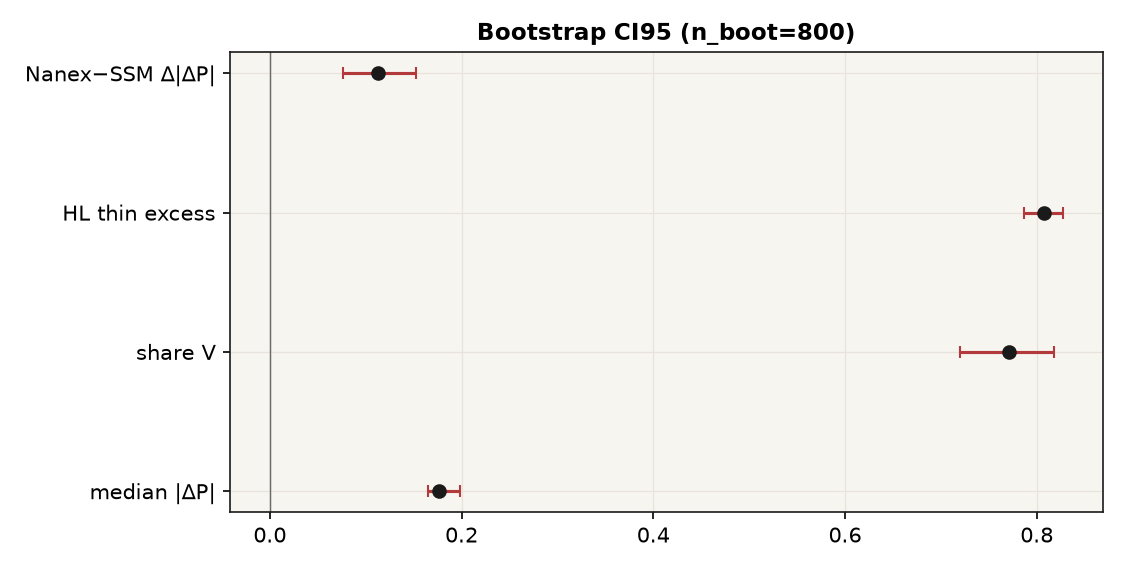

**fig_time_split.png**

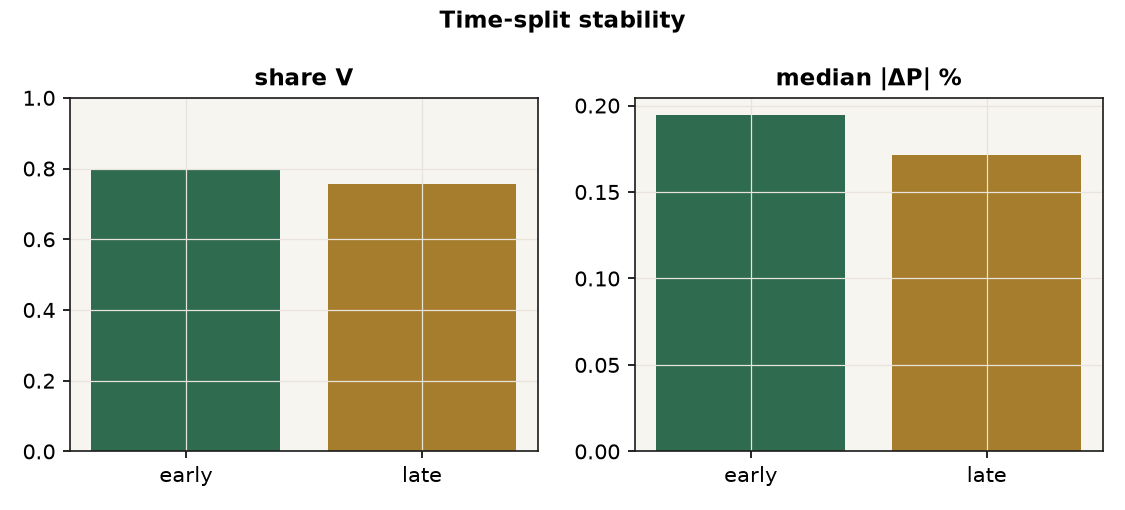

**fig_occurrence_roc.png**

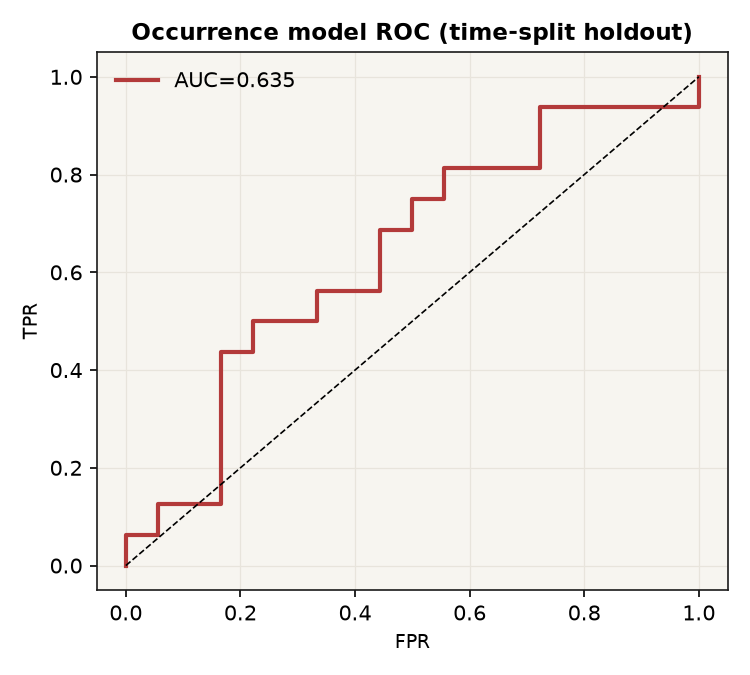

**fig_occurrence_calibration.png**

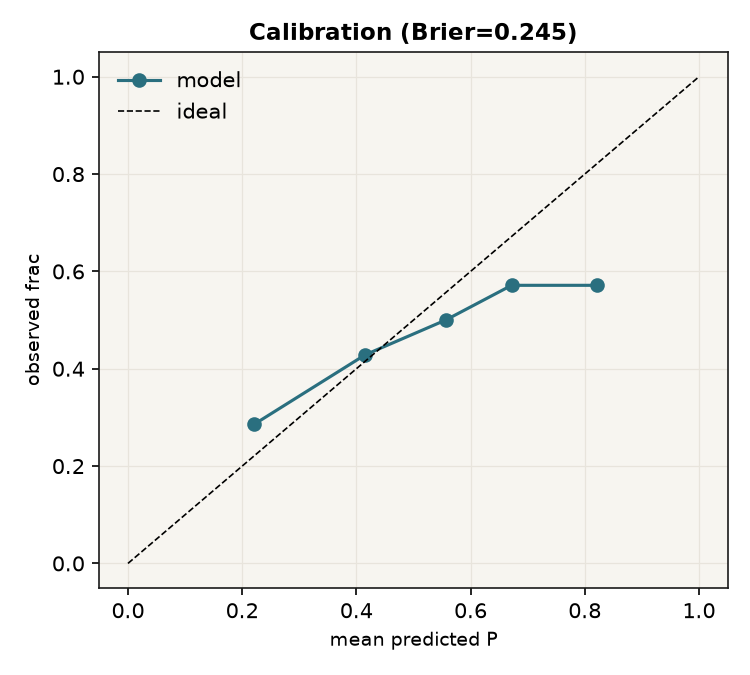

**fig_bayes_v_recovery.png**

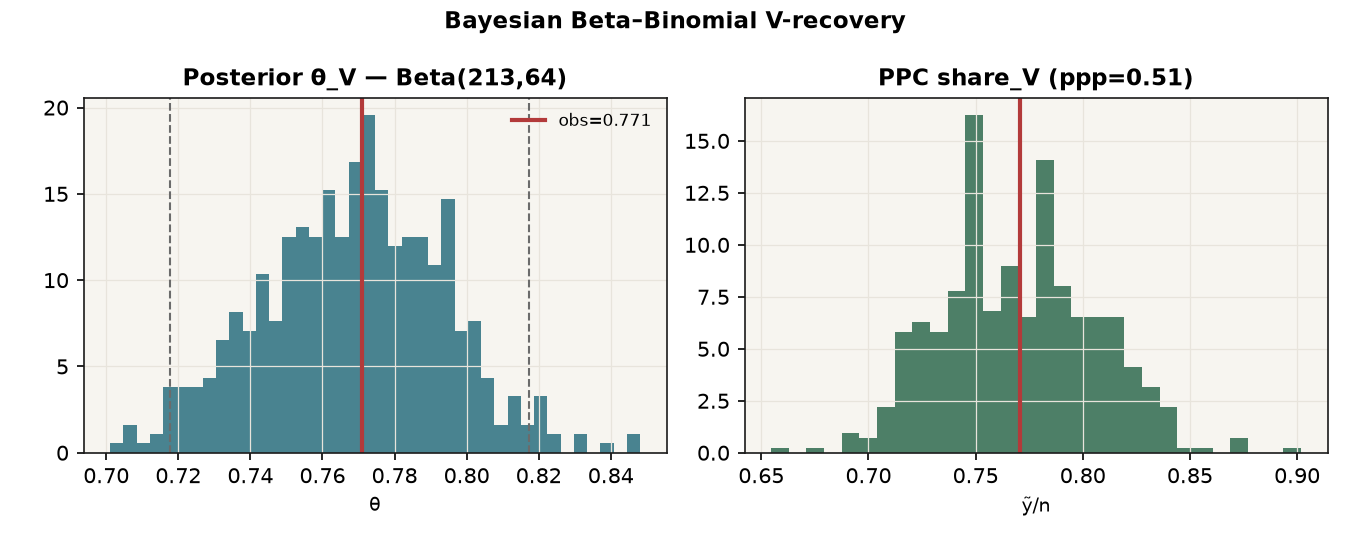

**fig_bayes_logistic_coefs.png**

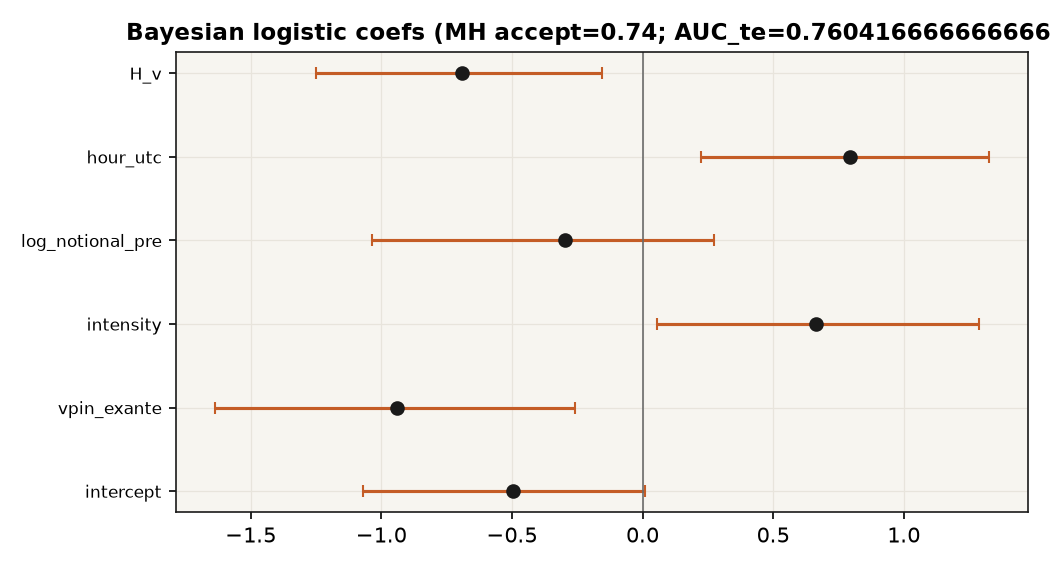

**fig_bayes_logistic_ppc.png**

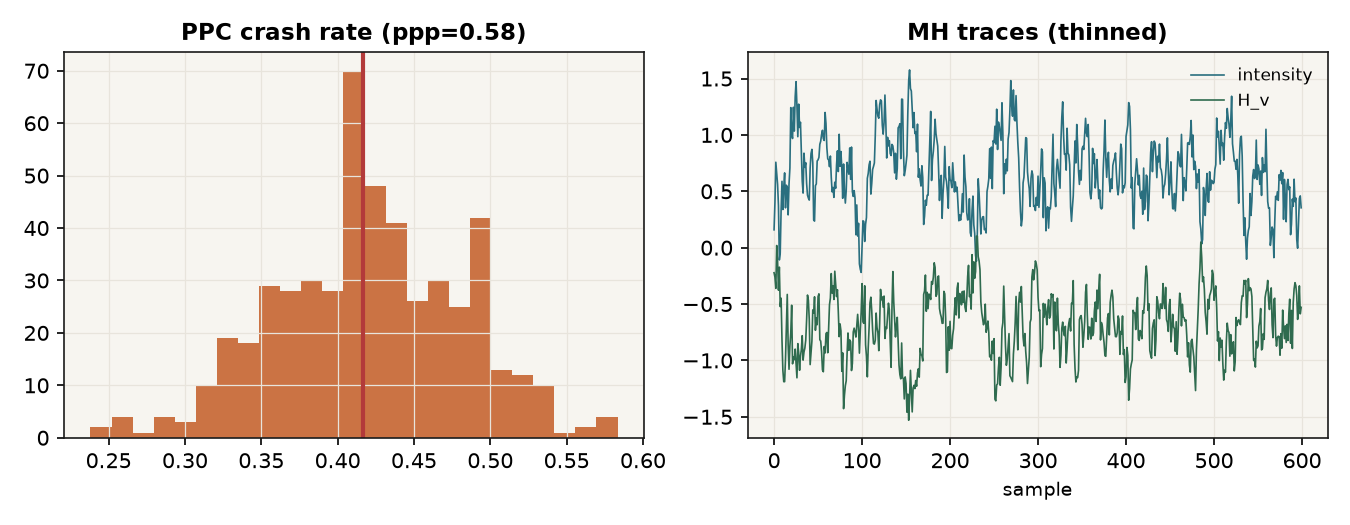

In [4]:

st = s.get('statistical') or {}
print('ROC AUC', (st.get('occurrence_roc') or {}).get('auc_test'))
bv = (s.get('bayesian') or {}).get('v_recovery') or {}
bo = (s.get('bayesian') or {}).get('occurrence') or {}
print('V posterior', (bv.get('posterior') or {}).get('mean'), (bv.get('posterior') or {}).get('ci95'))
print('logistic AUC_te', bo.get('posterior_mean_auc_holdout'), 'ppp', (bo.get('ppc') or {}).get('bayesian_pvalue'))
for name in [
    'fig_bootstrap_cis.png','fig_time_split.png','fig_occurrence_roc.png','fig_occurrence_calibration.png',
    'fig_bayes_v_recovery.png','fig_bayes_logistic_coefs.png','fig_bayes_logistic_ppc.png',
]:
    display(Markdown(f'**{name}**'))
    display(Image(filename=str(FIG/name)))


## Cross-links

- Feature models summary: `applications/feature_models/out/feature_models_summary.json`
- MM quoting figs: `applications/mm_quoting/out/figs/`
- Strategy lab equity (sibling): `applications/strategy_lab/out/figs/`
- Risk apps figs: `applications/out/{kill_ladder,nanex_burst,hl_thin_sor,hv_fei_capacity}/figs/`
